# Geographic Donation Analysis

Breakdown of donor giving by city, county, ZIP code, and state.

**Outlier control:** Donation totals per donor are highly skewed (most give $10–$50; a few give $1,000+).
We use **median**, **IQR**, **box plots**, and **winsorized mean** (caps at 5th/95th percentile)
instead of raw averages, so results reflect typical donor behavior rather than outlier influence.

In [38]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy.stats import mstats

# Load contributions
contrib = pd.read_csv(
    '../../All Contributions Ever 4.9.26.xls',
    encoding='utf-16', sep='\t', on_bad_lines='skip', low_memory=False
)
contrib['date'] = pd.to_datetime(contrib['Date Received'], errors='coerce')
contrib = contrib[contrib['date'].notna()].copy()
contrib['amount'] = pd.to_numeric(contrib['Amount'], errors='coerce').fillna(0)
contrib = contrib[contrib['amount'] > 0].copy()
contrib = contrib.rename(columns={'VANID': 'vanid'})
contrib = contrib[['vanid', 'date', 'amount']]

# Load contacts with location
contacts = pd.read_csv(
    '../../Database List 4.9.26.xls',
    encoding='utf-16', sep='\t', on_bad_lines='skip', low_memory=False
)
contacts = contacts.rename(columns={
    'VANID': 'vanid',
    'State/Province': 'state',
    'Zip/Postal': 'zip',
    'County': 'county',
    'City': 'city'
})[['vanid', 'city', 'county', 'state', 'zip']]

# Per-donor total giving (lifetime)
donor_totals = contrib.groupby('vanid')['amount'].sum().reset_index()
donor_totals.columns = ['vanid', 'total_given']

# Join location onto donor totals
donor_totals['vanid'] = donor_totals['vanid'].astype(str)
contacts['vanid'] = contacts['vanid'].astype(str)
donors = donor_totals.merge(contacts, on='vanid', how='left')

print(f'Donors with location data: {donors["state"].notna().sum():,} / {len(donors):,}')
print(f'Skew of total_given: {donors["total_given"].skew():.1f}  (>1 = right-skewed)')
donors['total_given'].describe().apply(lambda x: f'${x:,.0f}')

Donors with location data: 7,704 / 7,770
Skew of total_given: 68.0  (>1 = right-skewed)


count        $7,770
mean         $1,023
std         $14,961
min              $0
25%             $40
50%            $102
75%            $350
max      $1,201,162
Name: total_given, dtype: str

## Helper: outlier-aware summary stats

For each geographic group we compute:
- `n_donors` — number of unique donors
- `median` — middle value, unaffected by outliers
- `p25 / p75` — interquartile range (IQR)
- `winsorized_mean` — mean after capping top/bottom 5%; **only meaningful for n ≥ ~30**. For small groups, 5% winsorization may cap zero values, making winsorized mean equal to raw mean.
- `mean` — raw mean, shown for comparison

**For small groups (n < 30), rely on median and IQR rather than winsorized mean.**


In [39]:
def geo_summary(df, group_col, min_donors=20):
    """Summarize donor giving by geographic group, outlier-aware."""
    df = df[df[group_col].notna() & (df[group_col].str.strip() != '')].copy()
    result = (
        df.groupby(group_col)['total_given']
        .agg(
            n_donors='count',
            median='median',
            mean='mean',
            p25=lambda x: x.quantile(0.25),
            p75=lambda x: x.quantile(0.75),
            winsorized_mean=lambda x: mstats.winsorize(x, limits=[0.05, 0.05]).mean()
        )
        .reset_index()
    )
    result = result[result['n_donors'] >= min_donors].sort_values('median', ascending=False)
    return result

print('Helper defined.')

Helper defined.


## 1. By State (median + IQR, reliable sample states)

State-level groups vary a lot in sample size. The main chart only compares states with at least 30 donors; smaller states are shown separately as a caution table.

state  n_donors  median    mean  p25    p75  winsorized_mean
   MA        17    $300 $11,177 $100 $1,383          $11,177
   VA        19    $265    $943  $42   $710             $943
   DC        60    $250  $8,909  $96 $3,664           $4,421
   MD        20    $162    $858 $100   $450             $470
   NY        30    $155    $635  $25   $483             $577
   CA       175    $150  $3,033  $35   $662           $1,434
   PA        16    $127    $378  $42   $662             $378
   CO        31    $125    $239  $50   $300             $212
   IN        10    $122    $143  $35   $219             $143
   AZ      6935    $103    $916  $40   $350             $364
   NV        13    $103  $1,708  $25   $305           $1,708
   WA        42    $103    $355  $68   $290             $230
   NC        24    $100    $282  $34   $258             $263
   NJ        10    $100  $1,846  $62   $715           $1,846
   NM        14    $100  $1,726  $59   $365           $1,726
   MI        14    $100 

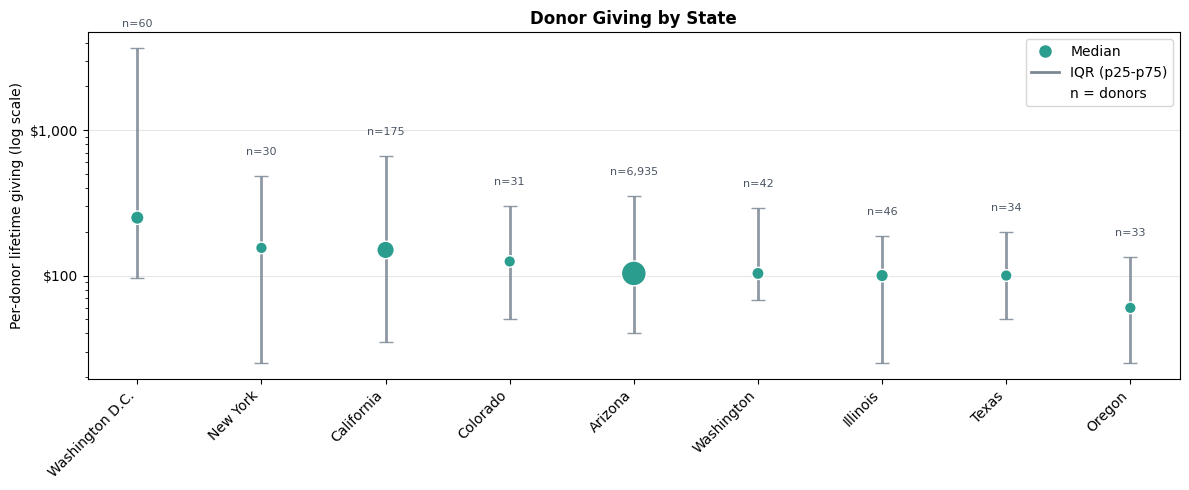

In [40]:
state_summary = geo_summary(donors, 'state', min_donors=10)
print(state_summary.to_string(index=False, float_format='${:,.0f}'.format))

MIN_STATE_DONORS = 30
reliable_states = state_summary[state_summary['n_donors'] >= MIN_STATE_DONORS].copy()
small_sample_states = state_summary[state_summary['n_donors'] < MIN_STATE_DONORS].copy()

print(f"\nMain chart includes states with at least {MIN_STATE_DONORS} donors.")
print("Small-sample states are excluded from the chart because outlier-control metrics are unstable when n is low.")
print("\nSmall-sample states (review cautiously):")
print(small_sample_states.to_string(index=False, float_format='${:,.0f}'.format))

STATE_NAMES = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DC': 'Washington D.C.',
    'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii',
    'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine',
    'MD': 'Maryland', 'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota',
    'MS': 'Mississippi', 'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska',
    'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico',
    'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island',
    'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas',
    'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington',
    'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
}

top_states = reliable_states.head(15)
state_labels = [STATE_NAMES.get(s, s) for s in top_states['state']]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(top_states))
yerr = np.vstack([
    top_states['median'] - top_states['p25'],
    top_states['p75'] - top_states['median']
])
sizes = np.clip(np.sqrt(top_states['n_donors']) * 12, 70, 320)

ax.errorbar(x, top_states['median'], yerr=yerr, fmt='none',
            ecolor='#7a8793', elinewidth=2, capsize=5, alpha=0.85, label='IQR (p25-p75)')
ax.scatter(x, top_states['median'], s=sizes, color='#2a9d8f',
           edgecolor='white', linewidth=1, zorder=5, label='Median')

for xi, (_, row) in zip(x, top_states.iterrows()):
    ax.text(xi, row['p75'] * 1.35, f"n={int(row['n_donors']):,}",
            ha='center', va='bottom', fontsize=8, color='#4b5563')

ax.set_xticks(x)
ax.set_xticklabels(state_labels, rotation=45, ha='right')
ax.set_ylabel('Per-donor lifetime giving (log scale)')
ax.set_title('Donor Giving by State', fontweight='bold')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.grid(axis='y', alpha=0.3)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='#2a9d8f', marker='o', linestyle='none', markersize=8, label='Median'),
    Line2D([0], [0], color='#7a8793', linewidth=2, label='IQR (p25-p75)'),
    Line2D([0], [0], linestyle='none', label='n = donors'),
]
ax.legend(handles=legend_handles)

plt.tight_layout()
plt.savefig('../figures/geo_state.png', dpi=150, bbox_inches='tight')
plt.show()


### Takeaways — By State

- The main chart includes **9 states** that meet the n≥30 threshold (DC, NY, CA, CO, AZ, WA, IL, TX, OR). States like MA (n=17) and VA (n=19) are excluded from the chart despite high medians because small samples make IQR unreliable.
- **Washington D.C.** leads all reliable states with median ~$250 and the widest IQR (p25~$96 to p75~$3,664) — indicating a mix of mid-level and major donors. The large gap between winsorized mean ($4,421) and median ($250) confirms a handful of very large donors pulling the average up significantly.
- **California** is the largest out-of-state reliable donor pool (n=175) with median $150, second only to DC in typical giving — a meaningful target for out-of-state cultivation.
- **New York** hits the minimum threshold (n=30) with median $155, comparable to CA, but with less certainty given the smaller sample.
- **Arizona** dominates in raw volume (n=6,935) but sits at median $103 — the fifth-highest among reliable states, confirming a broad base of small-dollar donors rather than a high-capacity one.
- **Oregon** has the lowest median (~$60) among all reliable states, notably below the $100 cluster shared by WA, IL, and TX.
- **Washington, Illinois, and Texas** cluster near $100 median, similar to AZ, but with much smaller donor pools (n=33–46).

## 2. By City (AZ only, top 15 by donor count)

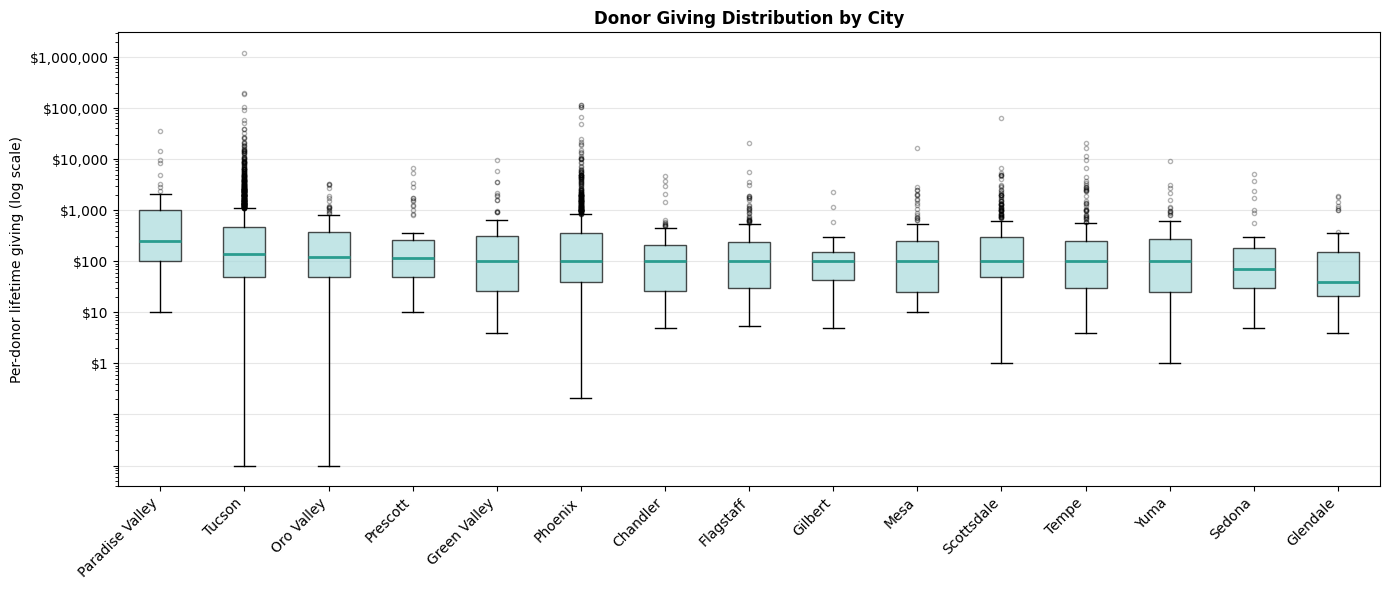

In [41]:
az_donors = donors[donors['state'] == 'AZ'].copy()
top_cities = az_donors['city'].value_counts().head(15).index
city_data = az_donors[az_donors['city'].isin(top_cities)]

city_order = (
    city_data.groupby('city')['total_given'].median()
    .sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(14, 6))
city_groups = [city_data[city_data['city'] == c]['total_given'].values for c in city_order]
bp = ax.boxplot(city_groups, patch_artist=True, showfliers=True,
                flierprops=dict(marker='o', markersize=3, alpha=0.3, color='#e76f51'),
                medianprops=dict(color='#2a9d8f', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('#a8dadc')
    patch.set_alpha(0.7)
ax.set_yscale('log')
ax.set_xticklabels(city_order, rotation=45, ha='right')
ax.set_ylabel('Per-donor lifetime giving (log scale)')
ax.set_title('Donor Giving Distribution by City', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}' if v >= 1 else ''))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/geo_city_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### Takeaways — By City (AZ)

- **Paradise Valley** has the highest median by a wide margin (visually ~$300–$400) and an elevated IQR floor — giving is consistently high across the board, not just driven by outliers. This is the strongest high-capacity city in the AZ donor base.
- **Tucson** is second in median (~$150) and likely the volume leader among AZ cities; it also has the most extreme outliers (whiskers extend to ~$1M), suggesting a handful of very large donors in addition to a solid mid-level base.
- **Oro Valley** and **Prescott** rank third and fourth in median (~$120–$130), with relatively compact IQRs — steady mid-level donor bases without heavy outlier influence.
- **Green Valley** and **Phoenix** follow with medians near $100–$110. Phoenix's IQR extends higher than most due to a large and varied donor pool.
- **Scottsdale** sits mid-pack with a median near $100–$120, similar to Phoenix despite its reputation as a wealthier area — worth investigating whether Scottsdale donors are underpenetrated.
- **Sedona** ranks near the bottom (median ~$75–$85), just above Glendale.
- **Glendale** has the lowest median (~$50) and the most compressed upper IQR of all 15 cities — a predominantly small-dollar donor profile.

## 3. By County (AZ only)

  county  n_donors  median   mean  p25  p75  winsorized_mean
    Pima      2922    $140 $1,346  $50 $475             $475
 Cochise        65    $100   $306  $35 $225             $157
Coconino       313    $100   $310  $30 $223             $201
Maricopa      3050    $100   $680  $35 $300             $321
   Pinal       145    $100   $445  $40 $257             $230
 Yavapai       190    $100   $333  $30 $200             $242
    Yuma        82    $100   $402  $25 $239             $273


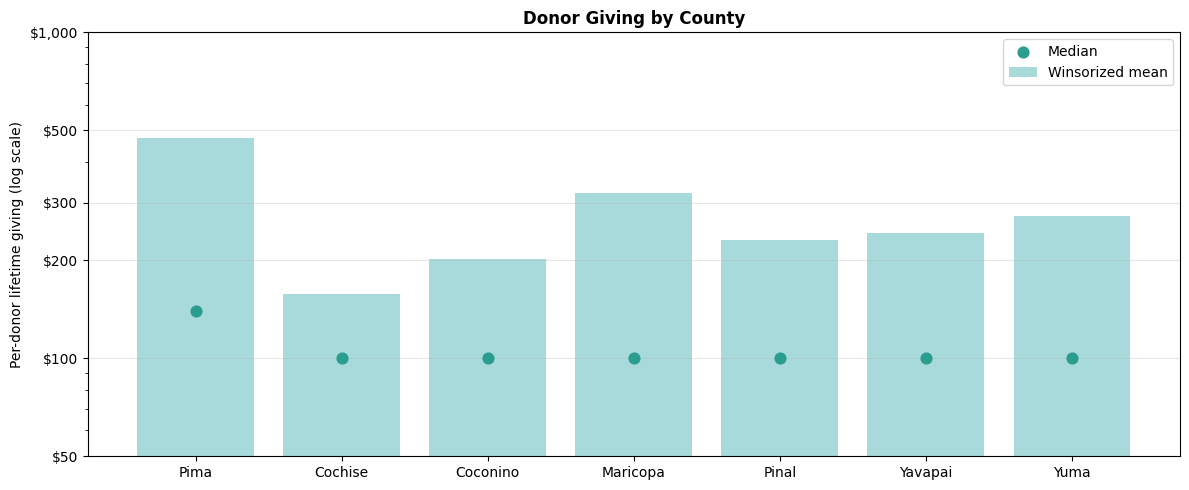

In [42]:
county_summary = geo_summary(az_donors, 'county', min_donors=30)
print(county_summary.to_string(index=False, float_format='${:,.0f}'.format))

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(county_summary))
ax.bar(x, county_summary['winsorized_mean'], color='#a8dadc', label='Winsorized mean')
ax.scatter(x, county_summary['median'], color='#2a9d8f', zorder=5, s=60, label='Median')
ax.set_xticks(list(x))
ax.set_xticklabels(county_summary['county'])
ax.set_ylabel('Per-donor lifetime giving (log scale)')
ax.set_title('Donor Giving by County', fontweight='bold')
ax.set_yscale('log')
yticks = [50, 100, 200, 300, 500, 1000]
ax.set_yticks(yticks)
ax.set_yticklabels([f'${v:,}' for v in yticks])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/geo_county.png', dpi=150, bbox_inches='tight')
plt.show()


### Takeaways — By County (AZ)

- **Pima County** (Tucson area) leads on both median ($140) and winsorized mean ($475) — the only county where the winsorized mean is substantially higher than others, indicating meaningful upper-tier donors in addition to a stronger typical base. It also has the second-largest donor pool (n=2,922).
- **Maricopa County** (Phoenix metro) has the largest donor pool (n=3,050) with median $100 and winsorized mean $310. High total revenue potential due to volume, but a broader mix of small and large donors.
- **All other counties** (Cochise, Coconino, Pinal, Yavapai, Yuma) share a median of ~$100 — the chart confirms a flat floor at this level across most of AZ.
- **Cochise County** has the lowest winsorized mean ($157) of any county in the chart, suggesting fewer high-capacity donors relative to its size.
- Counties with fewer than 30 donors (e.g., Navajo, Mohave) are excluded from the chart. Their metrics are too unstable to benchmark reliably; median is the only defensible summary for those counties until donor count grows.
- The $100 median is effectively the statewide baseline — Pima is the clear outlier above it, and Cochise is the one county that underperforms even on winsorized mean.

## 4. By ZIP Code (AZ only, top 20 by donor count)

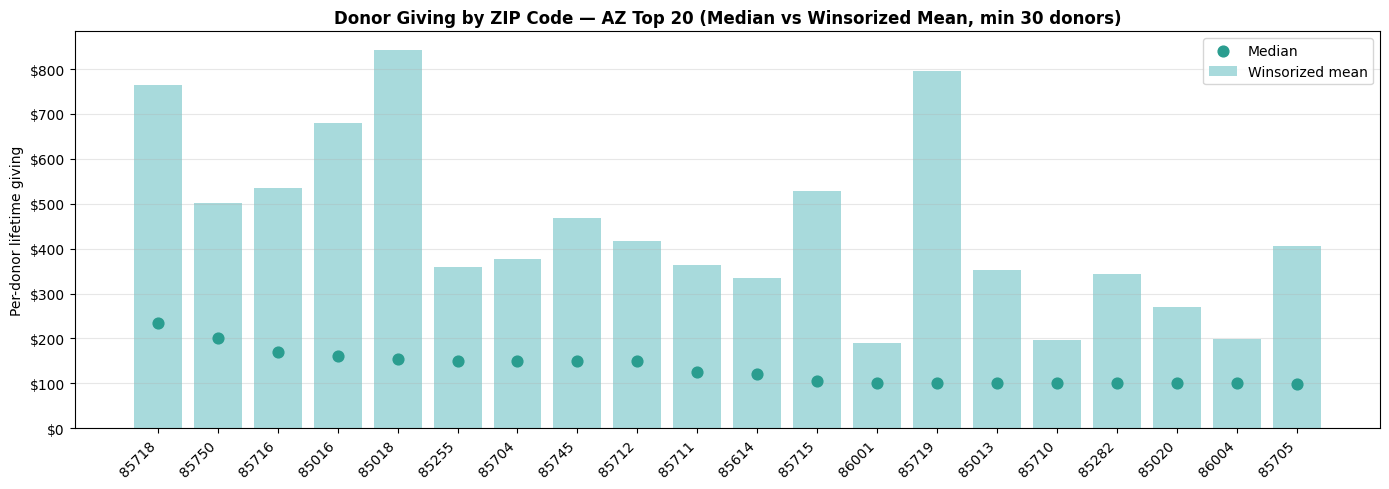

In [ ]:
# Extract only valid 5-digit ZIPs (astype(str) would turn NaN into 'nan')
az_donors = az_donors.copy()
az_donors['zip5'] = az_donors['zip'].astype(str).str.extract(r'(\d{5})')
az_donors = az_donors[az_donors['zip5'].notna()]

top_zips = az_donors['zip5'].value_counts().head(20).index
zip_data = az_donors[az_donors['zip5'].isin(top_zips)]

zip_summary = geo_summary(zip_data, 'zip5', min_donors=30).head(20)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(zip_summary))
ax.bar(x, zip_summary['winsorized_mean'], color='#a8dadc', label='Winsorized mean')
ax.scatter(x, zip_summary['median'], color='#2a9d8f', zorder=5, s=60, label='Median')
ax.set_xticks(list(x))
ax.set_xticklabels(zip_summary['zip5'], rotation=45, ha='right')
ax.set_ylabel('Per-donor lifetime giving')
ax.set_title('Donor Giving by ZIP Code', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/geo_zip.png', dpi=150, bbox_inches='tight')
plt.show()


### Takeaways — By ZIP Code (AZ)

- **85718** (Tucson, Catalina Foothills) has the highest median (~$240) and a high winsorized mean (~$765) — the top-performing ZIP on both dimensions, confirming a genuinely high-capacity donor base, not just outlier-driven.
- **85018** (Phoenix, Arcadia) has the highest winsorized mean (~$835) but a lower median (~$150), meaning a smaller number of very large donors elevate the average. Strong major-donor potential even if typical giving is moderate.
- **85719** (Tucson, midtown/university area) shows a dramatic gap: median ~$100 but winsorized mean ~$800 — even after capping extremes, average giving is very high, driven by concentrated large donors. Likely contains a few high-net-worth individuals.
- **85750, 85716, 85016** (Tucson east-side and Phoenix neighborhoods) form the next tier with medians in the $160–$200 range — solid mid-to-high capacity ZIPs.
- Most remaining ZIPs cluster at median $100–$115, consistent with the statewide baseline.
- **86001 and 86004** (Flagstaff area) have medians near $100 with moderate winsorized means — unremarkable giving profiles relative to the Tucson and Phoenix ZIPs.
- The large median-to-winsorized-mean gaps in 85018 and 85719 are the clearest signals of where major-donor prospecting is most likely to pay off.